In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [3]:
query = select(Feedback.json, Feedback.datetime).filter(
    Feedback.key_name == 'TDM_quitouts',
    Feedback.datetime >= datetime(2023, 9, 1))

In [53]:
df = pd.read_sql_query(query, session.connection())
df = df.join(pd.json_normalize(df.json.map(tdm_quitouts))).drop(['json'], axis=1)

In [20]:
def tdm_quitouts(x):
    total = 0
    for k in x['data'].values():
        total += sum(k.values())
    return {'quitouts': total}


In [17]:
query = select(Feedback.json, Round.id).join(Round).filter(
    Feedback.key_name == 'TDM_quitouts',
    Feedback.datetime >= datetime(2023, 9, 1))

In [21]:
df = df.join(pd.json_normalize(df.json.map(tdm_quitouts))).drop(['json'], axis=1)

In [18]:
df = pd.read_sql_query(query, session.connection())

In [58]:
df

,id,quitouts
0,37371,11
1,37372,13
2,37374,7
3,37379,11
4,37386,2
...,...,...
632,42791,6
633,42799,6
634,42811,6
635,42812,3


In [57]:
df.drop(['json'], axis=1)

KeyError: "['json'] not found in axis"

In [59]:
df.groupby(['quitouts']).count()

,id
quitouts,
1,70
2,72
3,71
4,62
5,66
6,62
7,39
8,27
9,28


In [112]:
len(df['quitouts'].unique())

32

<Axes: ylabel='Frequency'>

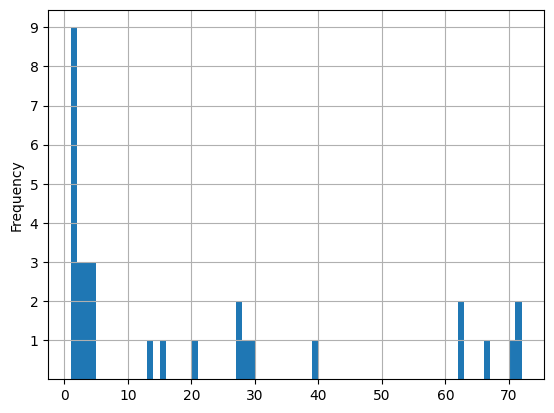

In [89]:
df.groupby(['quitouts']).count().plot(kind='hist', bins=71, grid=True, yticks=range(1, 10), legend=None)

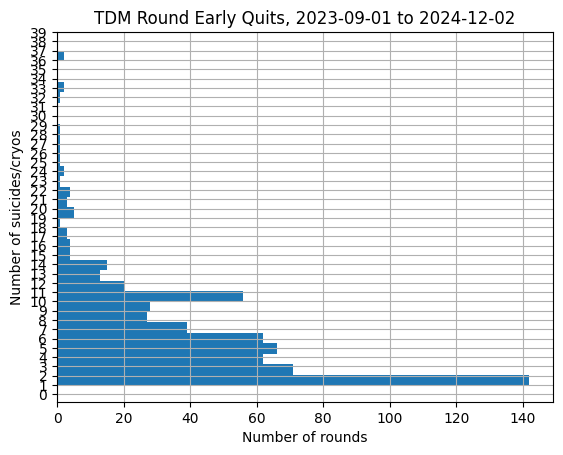

In [117]:
df['quitouts'].plot(kind='hist', orientation='horizontal', grid=True, bins=32, yticks=range(0, 40))
plt.title('TDM Round Early Quits, 2023-09-01 to 2024-12-02')
plt.ylabel('Number of suicides/cryos')
plt.xlabel('Number of rounds')
plt.savefig('tdm_cowards_hist-2023-09-01_2024-12-02.png')

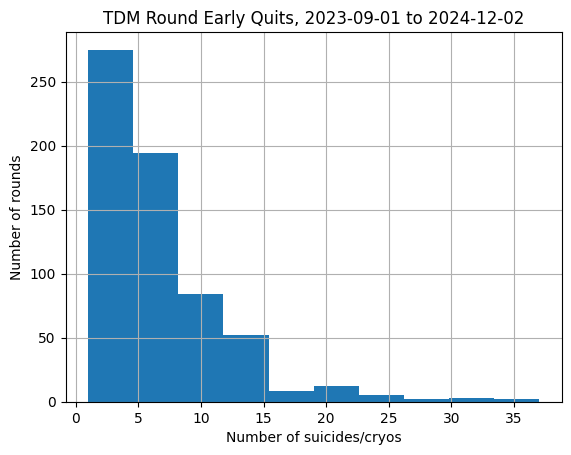

In [12]:
df['quitouts'].hist()
plt.title('TDM Round Early Quits, 2023-09-01 to 2024-12-02')
plt.xlabel('Number of suicides/cryos')
plt.ylabel('Number of rounds')
plt.savefig('tdm_cowards_hist-2023-09-01_2024-12-02.png')

In [28]:
df.resample('D', on='datetime')["quitouts"].sum().interpolate()[::7]

datetime
2023-09-20    42
2023-09-27     9
2023-10-04     3
2023-10-11     9
2023-10-18    24
2023-10-25    24
2023-11-01    12
2023-11-08    12
2023-11-15    10
2023-11-22     9
2023-11-29    12
2023-12-06    40
2023-12-13     0
2023-12-20    13
2023-12-27    13
2024-01-03    12
2024-01-10    26
2024-01-17     0
2024-01-24     9
2024-01-31     3
2024-02-07     6
2024-02-14    19
2024-02-21    24
2024-02-28     0
2024-03-06     4
2024-03-13    42
2024-03-20     0
2024-03-27    26
2024-04-03     3
2024-04-10     6
2024-04-17     0
2024-04-24     0
2024-05-01     8
2024-05-08    14
2024-05-15     0
2024-05-22     0
2024-05-29    10
2024-06-05    31
2024-06-12     6
2024-06-19    11
2024-06-26     0
2024-07-03     2
2024-07-10     0
2024-07-17     8
2024-07-24     9
2024-07-31     4
2024-08-07     0
2024-08-14    51
2024-08-21     1
2024-08-28     0
2024-09-04     4
2024-09-11     4
Freq: 7D, Name: quitouts, dtype: int64

In [17]:
resampled = df.resample('W-SUN', on='datetime')["quitouts"].mean().astype(int)

In [30]:
df

,datetime,quitouts
0,2023-09-20 15:19:18,11
1,2023-09-20 05:26:14,7
2,2023-09-20 02:30:26,13
3,2023-09-20 01:10:21,11
4,2023-09-21 03:30:49,2
...,...,...
513,2024-09-09 19:47:37,5
514,2024-09-09 08:04:34,1
515,2024-09-10 21:51:23,1
516,2024-09-10 04:58:09,3


In [21]:
df = df.join(pd.json_normalize(df.json.map(tdm_quitouts))).drop(['json'], axis=1)
df['dt'] = pd.to_datetime(df.datetime.dt.year.astype(str) + df.datetime.dt.month.astype(str), format='%Y%m')
df.drop(['datetime'], inplace=True, axis=1)

AttributeError: 'DataFrame' object has no attribute 'json'

In [22]:
df.drop(['round_id'], inplace=True, axis=1)

KeyError: "['round_id'] not found in axis"

In [ ]:
df

In [ ]:
df.groupby(['dt']).mean().astype(int)

In [29]:
resampled

datetime
2023-09-24     6
2023-10-01     7
2023-10-08     7
2023-10-15     5
2023-10-22    11
2023-10-29     7
2023-11-05     5
2023-11-12     8
2023-11-19     7
2023-11-26     5
2023-12-03     8
2023-12-10     6
2023-12-17     3
2023-12-24     6
2023-12-31     7
2024-01-07     6
2024-01-14     7
2024-01-21     6
2024-01-28     5
2024-02-04     7
2024-02-11     4
2024-02-18     5
2024-02-25     7
2024-03-03     6
2024-03-10     7
2024-03-17     8
2024-03-24     4
2024-03-31     8
2024-04-07     5
2024-04-14     6
2024-04-21     4
2024-04-28     8
2024-05-05     6
2024-05-12     7
2024-05-19     5
2024-05-26     6
2024-06-02     3
2024-06-09     7
2024-06-16     4
2024-06-23     7
2024-06-30     6
2024-07-07     5
2024-07-14     5
2024-07-21     6
2024-07-28     7
2024-08-04     7
2024-08-11     9
2024-08-18     6
2024-08-25     5
2024-09-01     5
2024-09-08     5
2024-09-15     2
Freq: W-SUN, Name: quitouts, dtype: int32

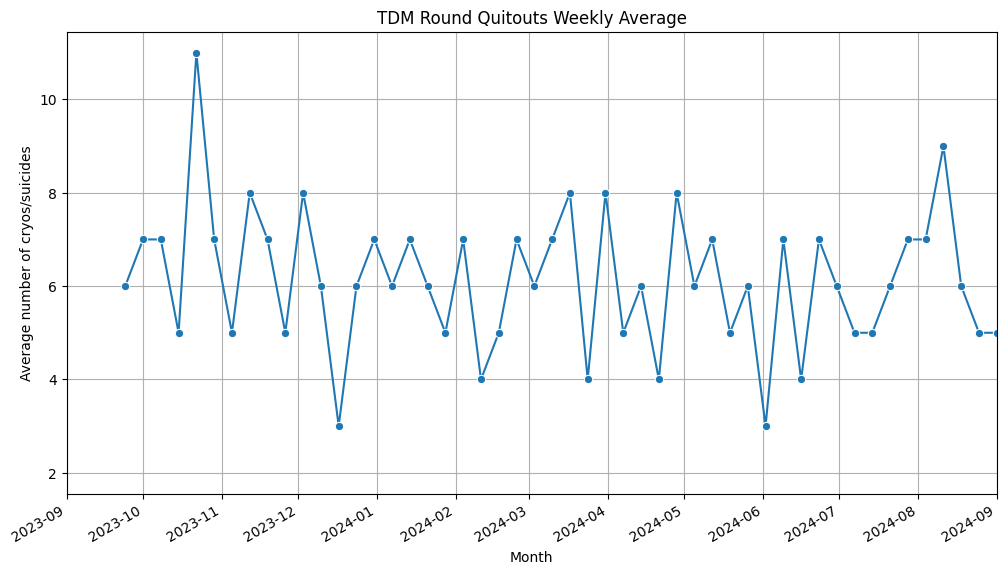

In [26]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
plot = sns.lineplot(
    data=resampled,
    marker='o',
    linestyle='solid',
    dashes=False,
)
plot.set(xlim=(date(2023, 9, 1), date(2024, 9, 1)))
plot.set(title='TDM Round Quitouts Weekly Average')
plot.set(xlabel='Month', ylabel='Average number of cryos/suicides')
months = mdates.MonthLocator(interval=1) 
ax.xaxis.set_major_locator(months)

for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax.grid()
plt.savefig("tdm_cowards_total.png")